<a href="https://colab.research.google.com/github/IOAI-official/IOAI-2026/blob/main/Home%20Task/Home-Task-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎧 Operation Night Watch: Teaching an Old Classifier New Sounds

Welcome! In this task you will take a **deployed audio event classifier** and teach it to recognize **13 brand-new sound classes** — *without* destroying what the model already knows.
## The story

Your company runs a network of low-power acoustic monitoring stations. The production model on these stations is an **Audio Spectrogram Transformer (AST)** that recognizes **16 everyday and wildlife sound classes**: dogs, roosters, thunderstorms, sea waves, even keyboard typing.

Two new customers just signed contracts:

- 🌲 **A national park** wants to detect **illegal logging and poaching activity**: axes, chainsaws, hand saws, generators, vehicle engines, helicopters, gunshots, fireworks, and crackling fires.
- 🦗 **An entomology institute** runs an acoustic insect survey and needs the model to distinguish **four singing insect species** by their calls: *Pterophylla camellifolia*, *Cicada orni*, *Gryllus campestris*, and *Tettigonia viridissima*.

That is **13 new classes**, and the upgraded model must keep serving the existing customers — so the 16 old classes must keep working too.

## Why can't we just retrain from scratch?

Your base model is built on Audio Spectrogram Transformer (AST). AST starts from large-scale ImageNet + AudioSet pre-training (millions of clips, GPU-weeks). Then the model was trained as a classifier for 16 base classes from `train.classes.csv`. Your budget is a **single GPU for up to 10 mins of training time**. The pre-trained model is a way to get strong audio features — treat it as a precious, irreplaceable artifact and build on top of it. Retraining the model from scratch on all data samples is too expensive.

## The rules

1. ✅ You **must start from the provided checkpoint** (`model/`) and reuse its encoder weights. You may add parameters (extra classifier rows, adapters, …) and fine-tune any subset of weights
2. ✅ Your final model must classify **all 29 classes** (16 old + 13 new) in a single forward pass
3. ❌ No training from scratch, and no other pre-trained audio models
4. ⏱️ Keep it lightweight: everything should run on a single GPU ~ 10 mins of training time

Your submission is scored as a **50/50 weighted average of accuracy on old classes and accuracy on new classes** (details in Section 4) — forgetting the old classes is exactly as costly as failing to learn the new ones.

# First things first: Set up Google Drive

In [ ]:
!pip -q install gdown
import gdown, random, os

# dataset.zip mirrors in your IOAI-2026/AudioClassifier/data folder. Each file ID has its
# own Google Drive download quota, so we try them in random order to survive heavy load.
# MIRRORS = [
#     "12XaRWYDsHq3eBwrgZ0QnEOffflS_dlff",   # dataset.zip
#     "1iUYDtKxXM1GSG5VNJ3r9847hqhWEiQRq",   # dataset_m2.zip
#     "112F9IFfn3_UtOPwSM1cGbuAL7Ci2aBP_",   # dataset_m3.zip
# ]
# random.shuffle(MIRRORS)

# ZIP = "dataset.zip"
# if not (os.path.exists(ZIP) and os.path.getsize(ZIP) > 10**9):
#     for fid in MIRRORS:
#         try:
#             gdown.download(id=fid, output=ZIP, quiet=False)
#         except Exception as e:
#             print("mirror failed:", fid, "->", e)
#         if os.path.exists(ZIP) and os.path.getsize(ZIP) > 10**9:
#             break
#         if os.path.exists(ZIP):
#             os.remove(ZIP)
#     else:
#         raise RuntimeError("All dataset mirrors are rate-limited right now. "
#                            "Wait ~30 min and re-run.")

!unzip -q -o dataset.zip -d /content/dataset

In [ ]:
from pathlib import Path

LOCAL_DATA_DIR = Path("/content/dataset")

if not LOCAL_DATA_DIR.exists():
    raise FileNotFoundError(
        "Dataset not found. Please run the dataset download/unzip cell first."
    )

print("Dataset found:")
for i in LOCAL_DATA_DIR.iterdir():
  print(i)

Dataset found:
/content/dataset/train.csv
/content/dataset/model
/content/dataset/audio
/content/dataset/__MACOSX
/content/dataset/fine_tune.csv


# 0. Setup

What you have inside the ```/content/audioclassifier_data```:

| Artifact | Description |
|---|---|
| `model/` | Pre-trained AST checkpoint (16-class classifier) |
| `train.csv` | The retained subset of the *old* data — 16 classes, `train`/`val` splits |
| `fine_tune.csv` | The *new* data — 13 classes, `train`/`val` splits |
| `audio/` | All audio clips (5 s, mono, 16 kHz `.wav`) |


In [ ]:
import json
import os
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Audio, HTML, display
from sklearn.manifold import TSNE
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from transformers import ASTFeatureExtractor, ASTForAudioClassification

warnings.filterwarnings("ignore")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

OLD_CSV = LOCAL_DATA_DIR / "train.csv"
NEW_CSV = LOCAL_DATA_DIR / "fine_tune.csv"
CHECKPOINT = LOCAL_DATA_DIR / "model"
SR = 16_000
BATCH_SIZE = 8
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

config = json.loads((CHECKPOINT / "config.json").read_text())
old_id2label = {int(k): v for k, v in config["id2label"].items()}
NUM_OLD = len(old_id2label)
print(f"device = {DEVICE} | checkpoint knows {NUM_OLD} classes")

device = cpu | checkpoint knows 16 classes


In [ ]:
old_df = pd.read_csv(OLD_CSV)

new_df = pd.read_csv(NEW_CSV)
new_df["target"] = new_df["target"]
new_id2label = dict(new_df[["target", "category"]].drop_duplicates().values)
new_id2label = {int(k): v for k, v in sorted(new_id2label.items())}

id2label = {**old_id2label, **new_id2label}            # all 29 classes
label2id = {v: k for k, v in id2label.items()}
NUM_TOTAL = len(id2label)
print(f"total classes after expansion: {NUM_TOTAL}")

total classes after expansion: 29


## 1. Meet the data

### The old world: 16 base classes

These are the classes the deployed model already recognizes. `train.csv` is the small retained subset — note how few training clips per class are left.


In [ ]:
old_summary = (old_df.groupby(["target", "category", "split"]).size()
               .unstack(fill_value=0)[["train", "val"]])
print(f"old-data clips: {len(old_df)}")
old_summary

old-data clips: 491


,split,train,val
target,category,,
0,Dog,12,8
1,Rooster,12,8
2,Pig,12,8
3,Cow,22,8
4,Frog,35,23
5,Cat,12,8
6,Hen,12,8
7,Sheep,3,8
8,Crow,12,8


Let's actually *listen*. Audio tasks reward using your ears — a confusion that looks mysterious in a table is often obvious after ten seconds of listening. Below: one **validation**-split sample for each of the 16 base classes.

In [ ]:
def get_example(df, target, split="val"):
    pool = df[df["split"].eq(split) & df["target"].eq(target)]
    row = pool.sample(1, random_state=0).iloc[0]
    wav, _ = librosa.load(LOCAL_DATA_DIR / row["path"], sr=SR, mono=True)
    return wav


def audio_grid(df, targets, ncols=4, split="val"):
    items = []
    for t in targets:
        wav = get_example(df, t, split)
        player = Audio(wav, rate=SR)._repr_html_().replace("<audio ", '<audio style="width:185px" ')
        items.append(f"<td style='text-align:center;padding:8px'><b>[{t}] {id2label[t]}</b><br>{player}</td>")
    rows = ["<tr>" + "".join(items[i:i + ncols]) + "</tr>" for i in range(0, len(items), ncols)]
    display(HTML("<table>" + "".join(rows) + "</table>"))


def play_examples(df, targets, split="val"):
    for t in targets:
        print(f"[{t:2d}] {id2label[t]}")
        display(Audio(get_example(df, t, split), rate=SR))


audio_grid(old_df, list(range(NUM_OLD)))

[0] Dog Your browser does not support the audio element.,[1] Rooster Your browser does not support the audio element.,[2] Pig Your browser does not support the audio element.,[3] Cow Your browser does not support the audio element.
[4] Frog Your browser does not support the audio element.,[5] Cat Your browser does not support the audio element.,[6] Hen Your browser does not support the audio element.,[7] Sheep Your browser does not support the audio element.
[8] Crow Your browser does not support the audio element.,[9] Mouse Click Your browser does not support the audio element.,[10] Keyboard Typing Your browser does not support the audio element.,[11] Thunderstorm Your browser does not support the audio element.
[12] Sea Waves Your browser does not support the audio element.,[13] Bird Chirping Your browser does not support the audio element.,[14] Wolf Howl Your browser does not support the audio element.,[15] Rain Your browser does not support the audio element.


### The new world: 13 new classes

The park-protection classes are mostly **mechanical / impulsive** sounds; the insect-survey classes are **periodic, narrow-band calls** that differ between species in subtle ways. Note the **class imbalance**: e.g. *Crackling Fire* has only 24 training clips, the insects have 60 each.

In [ ]:
new_summary = (new_df.groupby(["target", "category", "split"]).size()
               .unstack(fill_value=0)[["train", "val"]])
print(f"new-data clips: {len(new_df)}")
new_summary

new-data clips: 792


,split,train,val
target,category,,
16,Crackling Fire,24,8
17,Axe,45,15
18,Chainsaw,45,15
19,Generator,45,15
20,Hand Saw,45,15
21,Vehicle Engine,45,15
22,Helicopter,45,15
23,Gunshot,45,15
24,Firework,45,15


In [ ]:
play_examples(new_df, [16, 17, 18, 22, 23, 24, 25, 26])

[16] Crackling Fire


[17] Axe


[18] Chainsaw


[22] Helicopter


[23] Gunshot


[24] Firework


[25] Pterophylla Camellifolia


[26] Cicada Orni


## 3. Diagnostic tools: waveform & spectrogram

Here are some helpful diagnostic tools for working with audio:

- **Waveform** (amplitude vs. time) — reveals the *temporal envelope*: a gunshot is a single sharp transient, rain is a stationary wash, a cricket pulses rhythmically.
- **Log-mel spectrogram** (energy per mel-frequency band vs. time) — this is literally what the model sees. Insects concentrate energy in narrow high-frequency bands; engines sit in low-frequency harmonics; rain spreads energy everywhere.

Compare the four examples below — an impulse, an insect, a machine, and weather.


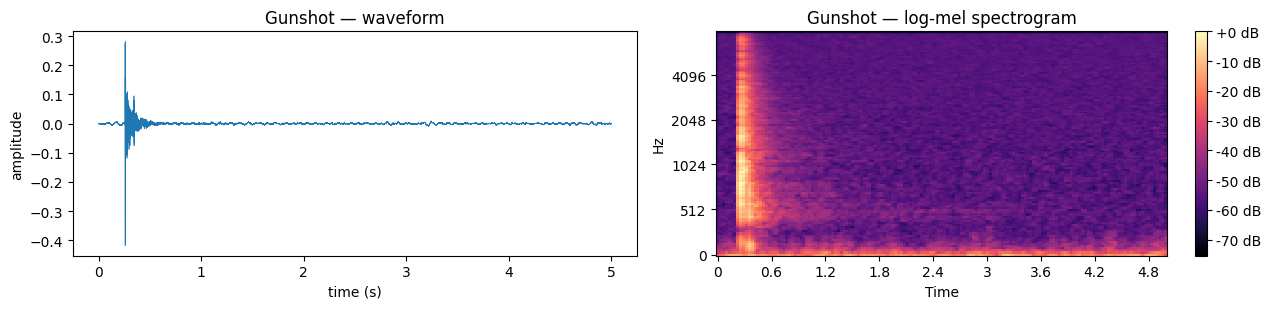

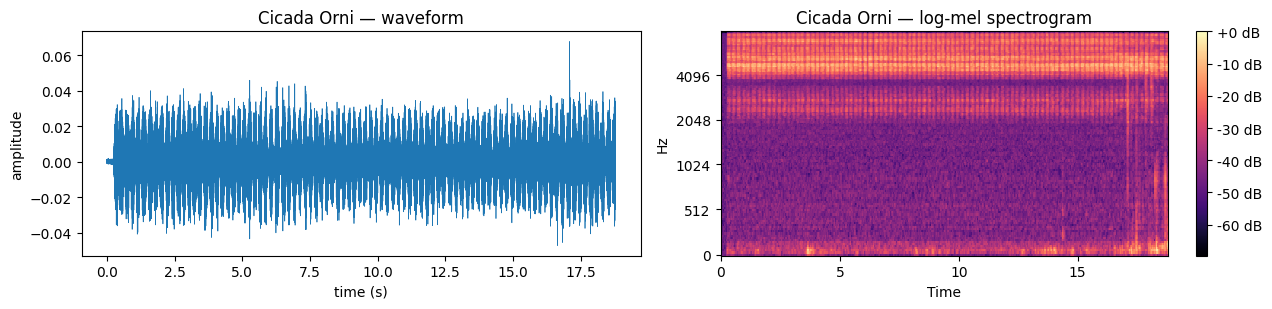

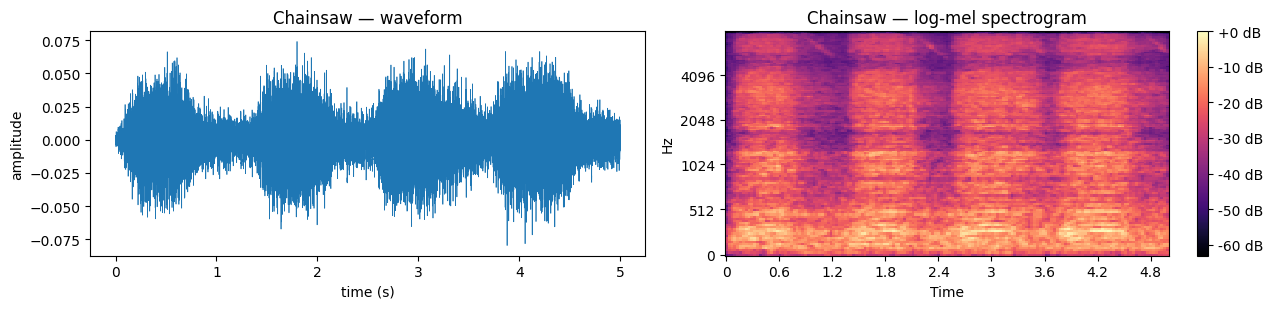

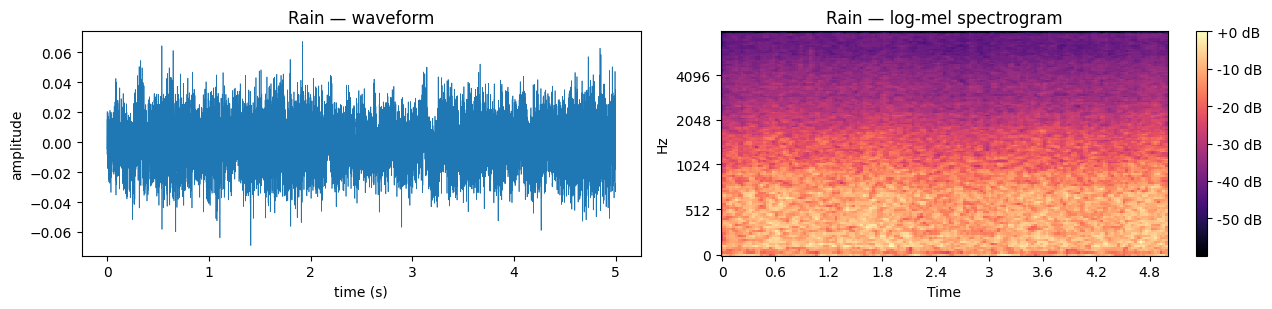

In [ ]:
def plot_waveform_and_spectrogram(path, title=""):
    wav, _ = librosa.load(path, sr=SR, mono=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
    axes[0].plot(np.arange(len(wav)) / SR, wav, linewidth=0.5, color="tab:blue")
    axes[0].set(title=f"{title} — waveform", xlabel="time (s)", ylabel="amplitude")
    S = librosa.feature.melspectrogram(y=wav, sr=SR, n_mels=128)
    img = librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=SR,
                                   x_axis="time", y_axis="mel", ax=axes[1], cmap="magma")
    axes[1].set(title=f"{title} — log-mel spectrogram")
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

all_df = pd.concat([old_df, new_df], ignore_index=True)
for t in [23, 26, 18, 15]:  # Gunshot, Cicada Orni, Chainsaw, Rain
    row = all_df[all_df["target"].eq(t) & all_df["split"].eq("val")].sample(1, random_state=0).iloc[0]
    plot_waveform_and_spectrogram(LOCAL_DATA_DIR / row["path"], id2label[t])

## 4. The model: Audio Spectrogram Transformer (AST)

The checkpoint in `model/` is an **Audio Spectrogram Transformer (AST)** ([Gong et al., *AST: Audio Spectrogram Transformer*, Interspeech 2021](https://arxiv.org/abs/2104.01778)). The key idea: **treat audio classification as image classification**.

![AST architecture](https://github.com/IOAI-official/IOAI-2026/blob/main/Home%20Task/images/ast.png?raw=1)

The pipeline:

1. The waveform is converted into a **128-band log-mel spectrogram** — a 2D "image" of shape `128 mel bins × 1024 time frames` (≈10 s, padded).
2. The spectrogram is cut into overlapping **16×16 patches**, each linearly projected to a 768-dim embedding (plus positional embeddings) — exactly like a Vision Transformer (ViT).
3. A stack of **12 Transformer encoder layers** lets every patch attend to every other patch — capturing both harmonic structure (across frequency) and temporal structure (across time).
4. The `[CLS]`-style tokens are pooled and a small **linear classification head** maps the 768-dim embedding to class logits.

Crucially, AST is initialized from **ImageNet-pre-trained ViT weights** and then pre-trained on **AudioSet** (~2M clips) before being fine-tuned for our 16 classes. That cascade of pre-training is what makes its features so strong — and what you cannot reproduce within this task's budget.

The architecture splits naturally into:
- the **encoder** (~86M parameters) — a general-purpose audio feature extractor, and
- the **head** - a tiny linear layer with 16 output rows

To support 29 classes you will need a head with 29 output rows. How you grow it — and how you fine-tune without forgetting — is the heart of this task.


In [ ]:
feature_extractor = ASTFeatureExtractor.from_pretrained(CHECKPOINT)
model = ASTForAudioClassification.from_pretrained(CHECKPOINT).to(DEVICE).eval()

total = sum(p.numel() for p in model.parameters())
head = sum(p.numel() for p in model.classifier.parameters())
print(f"total parameters:   {total / 1e6:.1f} M")
print(f"classifier head:    {head / 1e3:.1f} K  ({head / total:.3%} of the model)")

row = old_df[old_df["split"].eq("val")].iloc[0]
wav, _ = librosa.load(LOCAL_DATA_DIR / row["path"], sr=SR, mono=True)
feats = feature_extractor(wav, sampling_rate=SR, return_tensors="pt")
print(f"\nmodel input for one clip: {tuple(feats['input_values'].shape)}  (batch, time frames, mel bins)")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

total parameters:   86.2 M
classifier head:    13.8 K  (0.016% of the model)

model input for one clip: (1, 1024, 128)  (batch, time frames, mel bins)


## 5. Baseline model diagnostics: what does the pre-trained model do?

Before changing anything, **measure**. The helper below runs the model over a manifest and returns both predictions and **768-dim embeddings** (the pooled encoder output that feeds the head) — we'll need those for visualization.


In [ ]:
class AudioManifest(Dataset):
    def __init__(self, rows: pd.DataFrame):
        self.rows = rows.reset_index(drop=True)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows.iloc[index]
        wav, _ = librosa.load(LOCAL_DATA_DIR / row["path"], sr=SR, mono=True)
        return {"audio": wav.astype(np.float32), "label": int(row["target"])}


class Collator:
    def __init__(self, feature_extractor):
        self.feature_extractor = feature_extractor

    def __call__(self, batch):
        inputs = self.feature_extractor([item["audio"] for item in batch],
                                        sampling_rate=SR, padding=True, return_tensors="pt")
        inputs["labels"] = torch.tensor([item["label"] for item in batch])
        return inputs


@torch.no_grad()
def run_model(df: pd.DataFrame):
    loader = DataLoader(AudioManifest(df), batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=Collator(feature_extractor))
    preds, embs = [], []
    for batch in loader:
        out = model(batch["input_values"].to(DEVICE), output_hidden_states=True)
        h = out.hidden_states[-1]
        embs.append(((h[:, 0] + h[:, 1]) / 2).float().cpu().numpy())  # pooled CLS+distill tokens
        preds.append(out.logits.argmax(-1).cpu().numpy())

    return np.concatenate(preds), np.concatenate(embs)

In [ ]:
old_val = old_df[old_df["split"].eq("val")].reset_index(drop=True)
old_preds, old_embs = run_model(old_val)
acc_old = accuracy_score(old_val["target"], old_preds)
print(f"accuracy on the 16 old classes (val split): {acc_old:.2%}")

[array([0, 0, 0, 0, 0, 0, 0, 0]), array([1, 1, 1, 1, 1, 1, 1, 1]), array([2, 2, 2, 2, 2, 2, 2, 2]), array([3, 3, 3, 3, 3, 3, 3, 3]), array([4, 4, 4, 4, 4, 4, 4, 4]), array([4, 4, 4, 4, 4, 4, 4, 4]), array([4, 4, 4, 4, 4, 4, 4, 5]), array([5, 5, 5, 5, 5, 5, 5, 6]), array([6, 6, 6, 6, 6, 1, 6, 7]), array([7, 7, 7, 7, 7, 7, 7, 8]), array([ 8,  8,  8,  8,  8,  8,  8, 10]), array([ 9,  9,  9,  9,  9, 15,  9, 10]), array([10, 10, 10, 10, 10, 10, 10, 11]), array([11, 11, 11, 11, 11, 11, 11, 11]), array([11, 11, 11, 11, 11, 11, 11, 15]), array([11, 11, 11, 11, 11, 11, 12, 12]), array([12, 12, 12, 12, 12, 12, 13,  4]), array([13, 13, 13, 13, 13, 13, 13, 13]), array([13, 13, 13, 13, 13, 13, 13, 13]), array([13, 13, 13, 13, 13, 14, 14, 14]), array([14, 14, 14, 14, 14, 14, 14, 14]), array([14, 14, 14, 14, 15, 15, 15, 15]), array([15, 15, 15, 15, 15, 15, 15, 15]), array([15, 15, 15, 15, 15, 15, 15, 15]), array([15, 15, 15])] [array([[-0.03572451,  0.7834991 , -0.01891158, ..., -1.0481818 ,
        

### 5.1 - Confusion matrix on the old validation set

The model is doing a good job in classifying samples from old classes.


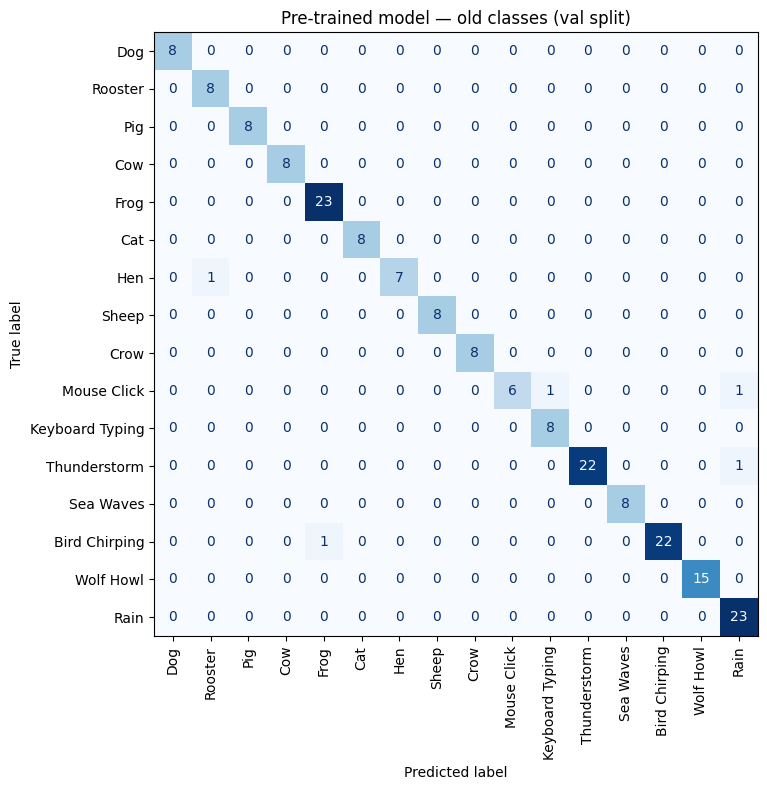

In [ ]:
cm = confusion_matrix(old_val["target"], old_preds, labels=range(NUM_OLD))
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=[old_id2label[i] for i in range(NUM_OLD)]).plot(
    ax=ax, xticks_rotation=90, cmap="Blues", colorbar=False)
ax.set_title("Pre-trained model — old classes (val split)")
plt.tight_layout()
plt.show()

### 5.2 - Where do the *new* sounds go?

The pre-trained model has never heard a chainsaw — but it still has to answer with one of its 16 classes. Watching *where* each new class lands tells you which old classes it sounds similar to, i.e. **where confusions (and forgetting pressure) will appear during fine-tuning**.


[array([15,  9, 15,  9, 15, 15,  9, 15]), array([15,  9,  9,  9, 13, 15, 15, 15]), array([15,  9, 15,  9,  9,  9, 13,  4]), array([ 4,  4, 14, 15, 15,  4,  9, 15]), array([ 9,  4,  4,  4, 13, 15,  4, 13]), array([15, 13, 15, 13, 15, 13, 13, 15]), array([15, 15, 15,  4,  4, 15, 15, 15]), array([15, 15, 15,  4, 13, 15,  9, 15]), array([15, 15, 15, 15, 13, 15, 15, 13]), array([15, 15, 15, 15, 15, 15, 15, 15]), array([15, 15, 15, 13, 13, 14, 15, 13]), array([13, 15, 13, 13,  0,  4, 13, 13]), array([13, 13, 15,  9, 11, 15, 11,  9]), array([ 9, 11, 15, 13, 11, 11, 15, 11]), array([ 9, 11, 11, 15, 11, 14, 11, 11]), array([11, 15, 15, 15, 11, 11, 15, 15]), array([13, 13, 13, 13, 13, 13, 13, 13]), array([13, 13, 13,  4,  4, 13,  4, 13]), array([ 4, 15,  4, 13, 13, 13,  4,  4]), array([13, 13,  4,  4, 13,  4, 15, 13]), array([13, 13, 13, 15, 15, 13, 13, 13])] [array([[-0.28022557,  0.14646007, -0.26357323, ..., -0.55114675,
        -0.9402326 ,  1.6255304 ],
       [ 0.22753677,  0.22781092,  0.

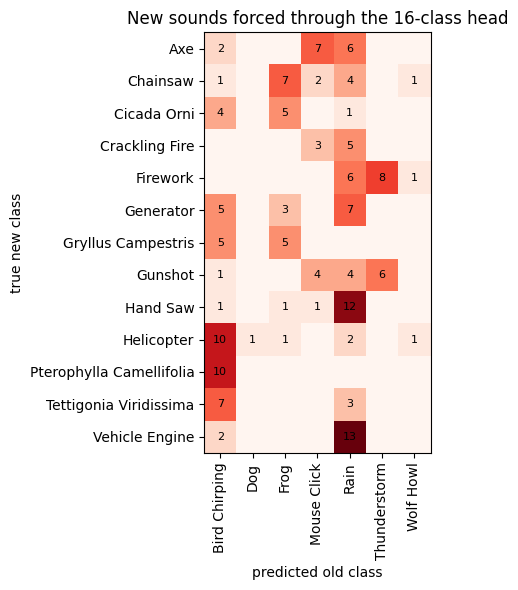

In [ ]:
new_val = new_df[new_df["split"].eq("val")].reset_index(drop=True)
new_preds, new_embs = run_model(new_val)

ct = pd.crosstab(new_val["category"], pd.Series(new_preds).map(old_id2label))
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(ct, cmap="Reds")
ax.set_xticks(range(ct.shape[1]), ct.columns, rotation=90)
ax.set_yticks(range(ct.shape[0]), ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        if ct.iloc[i, j]:
            ax.text(j, i, ct.iloc[i, j], ha="center", va="center", fontsize=8)
ax.set(xlabel="predicted old class", ylabel="true new class",
       title="New sounds forced through the 16-class head")
plt.tight_layout()
plt.show()

## 6 - Evaluation metric

Your model will be evaluated on a held-out test set covering **all 29 classes** in a single 29-way classification. The score is a **50/50 weighted average** of accuracy on old and new classes:

$$\text{Score} \;=\; \tfrac{1}{2}\,\text{Acc}_{\text{old}} \;+\; \tfrac{1}{2}\,\text{Acc}_{\text{new}}$$

where $\text{Acc}_{\text{old}}$ is accuracy over test clips whose true label is one of the 16 old classes, and $\text{Acc}_{\text{new}}$ over clips from the 13 new classes.


In [ ]:
def competition_score(y_true, y_pred) -> dict:
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    is_old = y_true < NUM_OLD
    acc_old = accuracy_score(y_true[is_old], y_pred[is_old])
    acc_new = accuracy_score(y_true[~is_old], y_pred[~is_old])
    return {"acc_old": acc_old, "acc_new": acc_new,
            "score": 0.5 * acc_old + 0.5 * acc_new}

baseline = competition_score(
    np.concatenate([old_val["target"], new_val["target"]]),
    np.concatenate([old_preds, new_preds]),
)
print("Pre-trained model baseline (local val splits):")
for k, v in baseline.items():
    print(f"  {k:8s} = {v:.2%}" if k != "score" else f"  {k:8s} = {v:.4f}")

Pre-trained model baseline (local val splits):
  acc_old  = 97.44%
  acc_new  = 0.00%
  score    = 0.4872


## Finally! Your mission

Build a 29-class model that maximizes the score. A suggested path:

1. **Fine-tune carefully**: naive training on `fine_tune.csv` alone will torch the old classes within a few hundred steps — watch it happen at least once, it's instructive.
2. **Fight forgetting**: mix in old clips from `train.csv` (experience replay — what ratio?), try knowledge distillation against the frozen original model, freeze or LoRA-ify parts of the encoder, tune learning rates per module.
3. **Diagnose relentlessly**: per-class accuracy over training, confusion matrices (which old class absorbs which new one?), embeddings, and your ears. The class imbalance in the new data (24–60 train clips per class) and acoustically-similar pairs (crickets vs. *Gryllus campestris*? rain vs. crackling fire?) are where points hide.
4. **Validate on `val`** — the final evaluation uses a hidden test set with the same metric.

Good luck — and remember: a model that learns everything new but forgets everything old scores no better than the one you started with. 🦉
